
# 06 · Factor Interpretation (Robust to Missing KS)

This notebook **interprets outputs from 05** and is **robust when `ks_shift` is missing** (e.g., no overlapping factor columns between train and test).  
If you provide optional raw dataset paths, it will try to **recompute KS on the fly**; otherwise it will **skip KS** cleanly and continue with IC/Sharpe-only analysis.

**Inputs (from 05):**
- `train_factor_scores.csv` — IC / Sharpe-like / efficiency per factor
- `train_test_factor_comparison.csv` — may include `ks_shift` (can be all NaN if no overlap)

**Optional (raw data, only if you want KS recomputed):**
- `TRAIN_CSV_RAW` — your `model_ready.csv`
- `TEST_CSV_RAW`  — your `test.csv` (or featured test)

**Outputs:**
- `factor_quality_index.csv` — composite ranking
- `factor_quality_summary.csv` — per-quality aggregates
- `factor_quality_categorized.csv` — full table with labels & cluster
- Plots (only if data available): KS histogram and Top-15 quality index


In [4]:

# ================== Parameters ==================
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- 05 outputs ---
FACTOR_SCORES_CSV = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\validation\train_factor_scores.csv"
FACTOR_COMPARISON_CSV = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\validation\train_test_factor_comparison.csv"

# --- Optional raw paths (leave as None if you don't want to recompute KS) ---
TRAIN_CSV_RAW = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\data\train.csv"  # e.g., r"C:\...\train.csv or model_ready_train.csv"
TEST_CSV_RAW  = TRAIN_CSV_RAW = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\data\test.csv" 
# --- Thresholds ---
KS_STRONG = 0.2
KS_UNSTABLE = 0.3

OUTPUT_DIR = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\interpretation"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [5]:

# -------- Load 05 outputs --------
scores = pd.read_csv(FACTOR_SCORES_CSV)                  # factor-level performance
comp   = pd.read_csv(FACTOR_COMPARISON_CSV)              # may or may not have ks_shift

# Compact view from scores
keep_cols = ["factor", "mean_ic", "adjusted_sharpe_like", "efficiency"]
scores_small = scores[[c for c in keep_cols if c in scores.columns]].copy()

# Merge with comp, preserving ks_shift if present
merged = scores_small.merge(comp[["factor","ks_shift"]] if "ks_shift" in comp.columns else comp[["factor"]], 
                            on="factor", how="left")
print("Loaded factors:", len(merged))
display(merged.head(5))

ks_available = ("ks_shift" in merged.columns) and merged["ks_shift"].notna().any()
print("KS available?", ks_available)


Loaded factors: 19


,factor,mean_ic,adjusted_sharpe_like,efficiency,ks_shift
0,market_forward_excess_returns,1.000000,0.485913,4342.538096,NaN
1,PROD_V1_MUL_P1,0.017819,0.015258,9.542934,NaN
2,LAG_V1_T20,0.013752,0.006072,2.832240,NaN
3,DELTA_S1_T2,-0.009742,0.004164,9.765122,NaN
4,DELTA_S1_T10,-0.008576,0.003237,2.468588,NaN


KS available? False


In [6]:

# -------- Optional: Recompute KS on the fly if missing and raw paths provided --------
def _ks_shift(a, b):
    a = pd.Series(a).dropna().values
    b = pd.Series(b).dropna().values
    if len(a) == 0 or len(b) == 0:
        return np.nan
    a_sorted, b_sorted = np.sort(a), np.sort(b)
    grid = np.unique(np.concatenate([a_sorted, b_sorted]))
    a_cdf = np.searchsorted(a_sorted, grid, side='right') / len(a_sorted)
    b_cdf = np.searchsorted(b_sorted, grid, side='right') / len(b_sorted)
    return float(np.max(np.abs(a_cdf - b_cdf)))

if not ks_available and (TRAIN_CSV_RAW and TEST_CSV_RAW):
    try:
        train_raw = pd.read_csv(TRAIN_CSV_RAW)
        test_raw  = pd.read_csv(TEST_CSV_RAW)
        factor_list = merged["factor"].dropna().unique().tolist()
        common = sorted(set(factor_list) & set(train_raw.columns) & set(test_raw.columns))
        print("Common factor columns found:", len(common))
        if len(common) > 0:
            ks_vals = {f: _ks_shift(train_raw[f], test_raw[f]) for f in common}
            merged = merged.merge(pd.Series(ks_vals, name="ks_shift_recalc").rename_axis("factor").reset_index(),
                                  on="factor", how="left")
            # prefer recalculated where available
            merged["ks_shift"] = merged["ks_shift"].combine_first(merged["ks_shift_recalc"])
            merged.drop(columns=["ks_shift_recalc"], inplace=True)
            ks_available = merged["ks_shift"].notna().any()
            print("KS recomputed for", len(common), "factors. KS now available?", ks_available)
        else:
            print("No overlapping factor names between raw train/test. KS remains unavailable.")
    except Exception as e:
        print("Could not recompute KS:", e)


Common factor columns found: 0
No overlapping factor names between raw train/test. KS remains unavailable.


In [8]:

# -------- Quality labeling --------
def label_quality(row, use_ks):
    ic_ok  = (row.get("mean_ic", 0) > 0)
    sh_ok  = (row.get("adjusted_sharpe_like", 0) > 0)
    if not use_ks:
        # KS not available: judge by IC/Sharpe only
        return "✅ Strong" if (ic_ok and sh_ok) else "⚠️ Moderate" if (ic_ok or sh_ok) else "❌ Unstable"
    else:
        ks = row.get("ks_shift", np.nan)
        if ic_ok and sh_ok and (ks < KS_STRONG):
            return "✅ Strong"
        if (not ic_ok) or (not sh_ok) or (ks >= KS_UNSTABLE):
            return "❌ Unstable"
        return "⚠️ Moderate"

merged["quality"] = merged.apply(lambda r: label_quality(r, ks_available), axis=1)
merged = merged.sort_values(["adjusted_sharpe_like","mean_ic"], ascending=False)
display(merged.head(15))


,factor,mean_ic,adjusted_sharpe_like,efficiency,ks_shift,quality
0,market_forward_excess_returns,1.000000,0.485913,4342.538096,NaN,✅ Strong
1,PROD_V1_MUL_P1,0.017819,0.015258,9.542934,NaN,✅ Strong
2,LAG_V1_T20,0.013752,0.006072,2.832240,NaN,✅ Strong
3,DELTA_S1_T2,-0.009742,0.004164,9.765122,NaN,⚠️ Moderate
4,DELTA_S1_T10,-0.008576,0.003237,2.468588,NaN,⚠️ Moderate
5,DELTA_S1_T5,-0.012728,-0.000302,6.132289,NaN,❌ Unstable
6,DELTA_V1_T2,-0.009204,-0.002349,17.836165,NaN,❌ Unstable
7,DELTA_P1_T2,0.012044,-0.003064,13.998793,NaN,⚠️ Moderate
8,LAG_S1_T60,-0.003001,-0.119519,0.213641,NaN,❌ Unstable
9,MOM_P1_T5,0.015425,-1.238505,0.538666,NaN,⚠️ Moderate


## KS Shift Distribution (skipped automatically if unavailable)

In [9]:

if ks_available and merged["ks_shift"].notna().any():
    plt.figure()
    merged["ks_shift"].dropna().hist(bins=20)
    plt.title("KS Shift Distribution (smaller is more stable)")
    plt.xlabel("KS Shift")
    plt.ylabel("Number of factors")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/ks_shift_hist.png", dpi=160)
    plt.show()
else:
    print("KS shift not available — skipping histogram.")


KS shift not available — skipping histogram.


## Factor Clustering (always runs; fills missing KS with 0)

In [10]:

X = merged[["mean_ic", "adjusted_sharpe_like"]].copy()
X["ks_shift"] = merged["ks_shift"].fillna(0.0)  # harmless when KS missing
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init=20, random_state=0)
merged["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:", merged["cluster"].value_counts().to_dict())
display(merged.groupby("cluster")[["mean_ic","adjusted_sharpe_like","ks_shift"]].mean())


Cluster sizes: {0: 17, 2: 1, 1: 1}


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,mean_ic,adjusted_sharpe_like,ks_shift
cluster,,,
0,0.004680,-6.711382,NaN
1,0.019302,-4359.352546,NaN
2,1.000000,0.485913,NaN


## Composite Factor Quality Index

In [11]:

r_ic  = merged["mean_ic"].rank(method="average", ascending=False)
r_sh  = merged["adjusted_sharpe_like"].rank(method="average", ascending=False)
r_ks  = (-merged["ks_shift"].fillna(0.0)).rank(method="average", ascending=False)  # smaller KS better
merged["quality_index"] = (r_ic + r_sh + r_ks) / 3.0

ranked = merged.sort_values("quality_index", ascending=False)
display(ranked.head(20))

ranked.to_csv(f"{OUTPUT_DIR}/factor_quality_index.csv", index=False)
print("Saved:", f"{OUTPUT_DIR}/factor_quality_index.csv")


,factor,mean_ic,adjusted_sharpe_like,efficiency,ks_shift,quality,cluster,quality_index
13,RATIO_V1_DIV_S1,-0.006840,-14.094860,0.035745,NaN,❌ Unstable,0,13.000000
17,MOM_S1_T60,0.010124,-32.831723,0.023574,NaN,⚠️ Moderate,0,12.666667
16,MOM_S1_T5,0.007806,-20.562417,0.028504,NaN,⚠️ Moderate,0,12.666667
12,MOM_V1_T5,-0.006362,-5.164525,0.081125,NaN,❌ Unstable,0,12.333333
5,DELTA_S1_T5,-0.012728,-0.000302,6.132289,NaN,❌ Unstable,0,11.666667
6,DELTA_V1_T2,-0.009204,-0.002349,17.836165,NaN,❌ Unstable,0,11.333333
11,MOM_P1_T20,0.004910,-3.196404,0.091875,NaN,⚠️ Moderate,0,11.333333
18,Unnamed: 0,0.019302,-4359.352546,0.000349,NaN,⚠️ Moderate,1,10.666667
3,DELTA_S1_T2,-0.009742,0.004164,9.765122,NaN,⚠️ Moderate,0,10.666667
8,LAG_S1_T60,-0.003001,-0.119519,0.213641,NaN,❌ Unstable,0,10.666667


Saved: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\interpretation/factor_quality_index.csv


## Exports: Quality Breakdown & Full Categorized Table

Saved: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\interpretation/factor_quality_summary.csv


mean_ic                 adjusted_sharpe_like                  \
                 mean    median count                 mean    median count   
quality                                                                      
⚠️ Moderate  0.009584  0.012044    11          -404.916892 -3.196404    11   
✅ Strong     0.343857  0.017819     3             0.169081  0.015258     3   
❌ Unstable  -0.007627 -0.006840     5            -3.876311 -0.119519     5   

            ks_shift               
                mean median count  
quality                            
⚠️ Moderate      NaN    NaN     0  
✅ Strong         NaN    NaN     0  
❌ Unstable       NaN    NaN     0

Saved: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\interpretation/factor_quality_categorized.csv


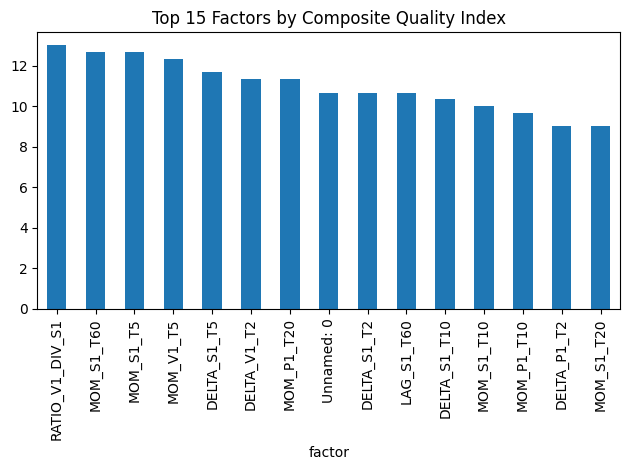

In [12]:

quality_summary = merged.groupby("quality")[["mean_ic","adjusted_sharpe_like","ks_shift"]].agg(["mean","median","count"])
quality_summary.to_csv(f"{OUTPUT_DIR}/factor_quality_summary.csv")
print("Saved:", f"{OUTPUT_DIR}/factor_quality_summary.csv")
display(quality_summary)

merged.to_csv(f"{OUTPUT_DIR}/factor_quality_categorized.csv", index=False)
print("Saved:", f"{OUTPUT_DIR}/factor_quality_categorized.csv")

# Optional chart
plt.figure()
ranked.head(15).set_index("factor")["quality_index"].plot(kind="bar")
plt.title("Top 15 Factors by Composite Quality Index")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top15_quality_index.png", dpi=160)
plt.show()
